<a href="https://colab.research.google.com/github/vitorbsilvadev1/Exercicios-logica-javascript/blob/main/TelecomX_BR_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd

In [61]:
dados = pd.read_csv('/content/telecomXlimpo.csv')

In [62]:
dados

,id_cliente,churn,genero,idoso,parceiro,dependentes,meses_contrato,servico_telefone,multiplas_linhas,servico_internet,...,protecao_dispositivo,suporte_tecnico,tv_streaming,filmes_streaming,tipo_contrato,fatura_digital,metodo_pagamento,gasto_mensal,gasto_total,gasto_diario
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,No,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7039,9992-RRAMN,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7040,9992-UJOEL,No,Male,No,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7041,9993-LHIEB,No,Male,No,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


In [63]:
dados['servico_internet'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

### Preparação dos dados

###### Analisando os dados

In [64]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7043 non-null   object 
 1   churn                 7043 non-null   object 
 2   genero                7043 non-null   object 
 3   idoso                 7043 non-null   object 
 4   parceiro              7043 non-null   object 
 5   dependentes           7043 non-null   object 
 6   meses_contrato        7043 non-null   int64  
 7   servico_telefone      7043 non-null   object 
 8   multiplas_linhas      7043 non-null   object 
 9   servico_internet      7043 non-null   object 
 10  seguranca_online      7043 non-null   object 
 11  backup_online         7043 non-null   object 
 12  protecao_dispositivo  7043 non-null   object 
 13  suporte_tecnico       7043 non-null   object 
 14  tv_streaming          7043 non-null   object 
 15  filmes_streaming     

###### Removendo dados desnecessários

In [65]:
dados_limpos = dados.drop(['id_cliente', 'genero', 'servico_telefone'], axis=1)

# a coluna multiplas_linhas já diz se tem serviço de telefone

###### Encoding - Transformando dados textuais em números (0 e 1)

1 - Mapeando colunas binárias

In [67]:
dados_limpos.describe(include='O')

,churn,idoso,parceiro,dependentes,multiplas_linhas,servico_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,tv_streaming,filmes_streaming,tipo_contrato,fatura_digital,metodo_pagamento
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,No,No,No,No,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,5174,5901,3641,4933,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365


In [68]:
colunas_binarias = dados_limpos[['churn', 'idoso',	'parceiro', 'dependentes', 'fatura_digital']]

In [69]:
colunas_binarias

,churn,idoso,parceiro,dependentes,fatura_digital
0,No,No,Yes,Yes,Yes
1,No,No,No,No,No
2,Yes,No,No,No,Yes
3,Yes,Yes,Yes,No,Yes
4,Yes,Yes,Yes,No,Yes
...,...,...,...,...,...
7038,No,No,No,No,No
7039,Yes,No,Yes,No,Yes
7040,No,No,No,No,Yes
7041,No,No,Yes,Yes,No


In [70]:
for col in colunas_binarias:
  dados_limpos[col] = dados_limpos[col].map({'Yes': 1, 'No': 0})

In [71]:
dados_limpos

,churn,idoso,parceiro,dependentes,meses_contrato,multiplas_linhas,servico_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,tv_streaming,filmes_streaming,tipo_contrato,fatura_digital,metodo_pagamento,gasto_mensal,gasto_total,gasto_diario
0,0,0,1,1,9,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.19
1,0,0,0,0,9,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,2.00
2,1,0,0,0,4,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.46
3,1,1,1,0,13,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.27
4,1,1,1,0,3,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,13,No,DSL,Yes,No,No,Yes,No,No,One year,0,Mailed check,55.15,742.90,1.84
7039,1,0,1,0,22,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,1,Electronic check,85.10,1873.70,2.84
7040,0,0,0,0,2,No,DSL,No,Yes,No,No,No,No,Month-to-month,1,Mailed check,50.30,92.75,1.68
7041,0,0,1,1,67,No,DSL,Yes,No,Yes,Yes,No,Yes,Two year,0,Mailed check,67.85,4627.65,2.26


get_dummies() para converter colunas categóricas não binárias em binárias

In [73]:
dados_encoded = pd.get_dummies(dados_limpos, dtype=int)

In [74]:
dados_encoded

,churn,idoso,parceiro,dependentes,meses_contrato,fatura_digital,gasto_mensal,gasto_total,gasto_diario,multiplas_linhas_No,...,filmes_streaming_No,filmes_streaming_No internet service,filmes_streaming_Yes,tipo_contrato_Month-to-month,tipo_contrato_One year,tipo_contrato_Two year,metodo_pagamento_Bank transfer (automatic),metodo_pagamento_Credit card (automatic),metodo_pagamento_Electronic check,metodo_pagamento_Mailed check
0,0,0,1,1,9,1,65.60,593.30,2.19,1,...,1,0,0,0,1,0,0,0,0,1
1,0,0,0,0,9,0,59.90,542.40,2.00,0,...,0,0,1,1,0,0,0,0,0,1
2,1,0,0,0,4,1,73.90,280.85,2.46,1,...,1,0,0,1,0,0,0,0,1,0
3,1,1,1,0,13,1,98.00,1237.85,3.27,1,...,0,0,1,1,0,0,0,0,1,0
4,1,1,1,0,3,1,83.90,267.40,2.80,1,...,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,0,0,13,0,55.15,742.90,1.84,1,...,1,0,0,0,1,0,0,0,0,1
7039,1,0,1,0,22,1,85.10,1873.70,2.84,0,...,0,0,1,1,0,0,0,0,1,0
7040,0,0,0,0,2,1,50.30,92.75,1.68,1,...,1,0,0,1,0,0,0,0,0,1
7041,0,0,1,1,67,0,67.85,4627.65,2.26,1,...,0,0,1,0,0,1,0,0,0,1


In [75]:
dados_encoded.columns

Index(['churn', 'idoso', 'parceiro', 'dependentes', 'meses_contrato',
       'fatura_digital', 'gasto_mensal', 'gasto_total', 'gasto_diario',
       'multiplas_linhas_No', 'multiplas_linhas_No phone service',
       'multiplas_linhas_Yes', 'servico_internet_DSL',
       'servico_internet_Fiber optic', 'servico_internet_No',
       'seguranca_online_No', 'seguranca_online_No internet service',
       'seguranca_online_Yes', 'backup_online_No',
       'backup_online_No internet service', 'backup_online_Yes',
       'protecao_dispositivo_No', 'protecao_dispositivo_No internet service',
       'protecao_dispositivo_Yes', 'suporte_tecnico_No',
       'suporte_tecnico_No internet service', 'suporte_tecnico_Yes',
       'tv_streaming_No', 'tv_streaming_No internet service',
       'tv_streaming_Yes', 'filmes_streaming_No',
       'filmes_streaming_No internet service', 'filmes_streaming_Yes',
       'tipo_contrato_Month-to-month', 'tipo_contrato_One year',
       'tipo_contrato_Two year', 'me

###### Calculando proporção de churn

In [76]:
dados_encoded['churn'].value_counts(normalize=True) * 100

,proportion
churn,
0,73.463013
1,26.536987


### Correlação e seleção de variáveis

Quais variáveis apresentam maior correlação com a evasão:

  - Análise prévia antes de treinar o modelo
  - Me ajudou na decisão de remover a coluna de gênero

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
churn_corr = dados_encoded.corr()['churn'].sort_values(ascending=False).drop('churn')
churn_corr

,churn
tipo_contrato_Month-to-month,0.405103
seguranca_online_No,0.342637
suporte_tecnico_No,0.337281
servico_internet_Fiber optic,0.308020
metodo_pagamento_Electronic check,0.301919
backup_online_No,0.268005
protecao_dispositivo_No,0.252481
gasto_diario,0.193412
gasto_mensal,0.193356
fatura_digital,0.191825


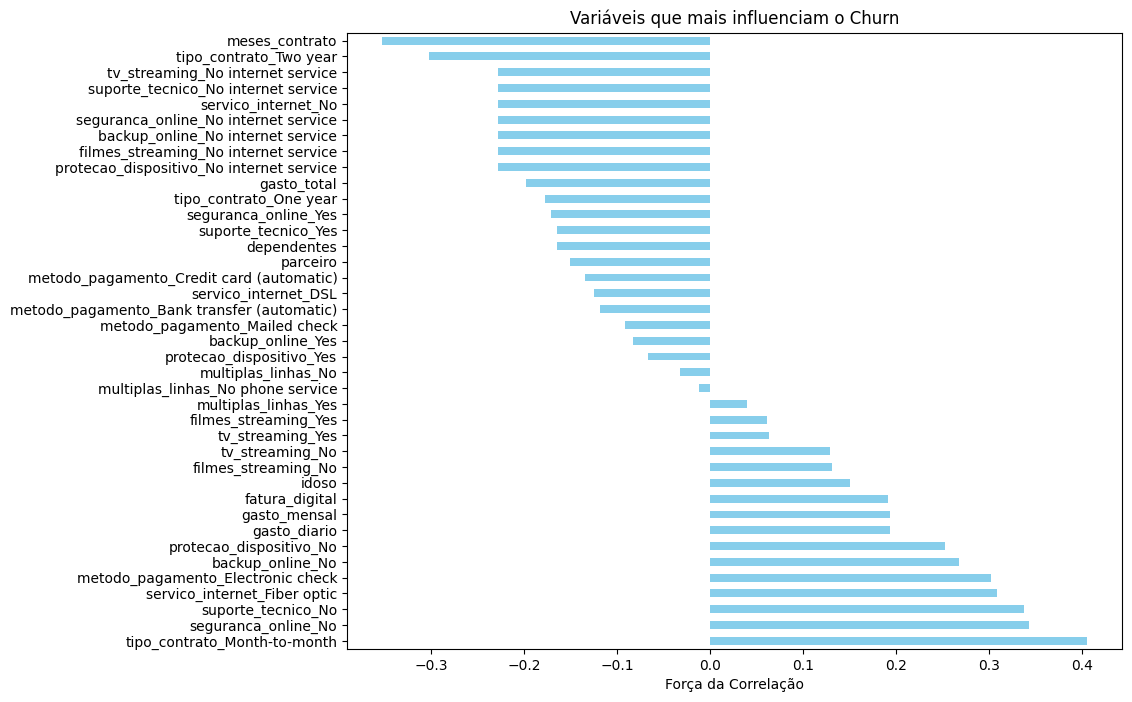

In [80]:
plt.figure(figsize=(10, 8))
churn_corr.plot(kind='barh', color='skyblue')
plt.title('Variáveis que mais influenciam o Churn')
plt.xlabel('Força da Correlação')
plt.show()

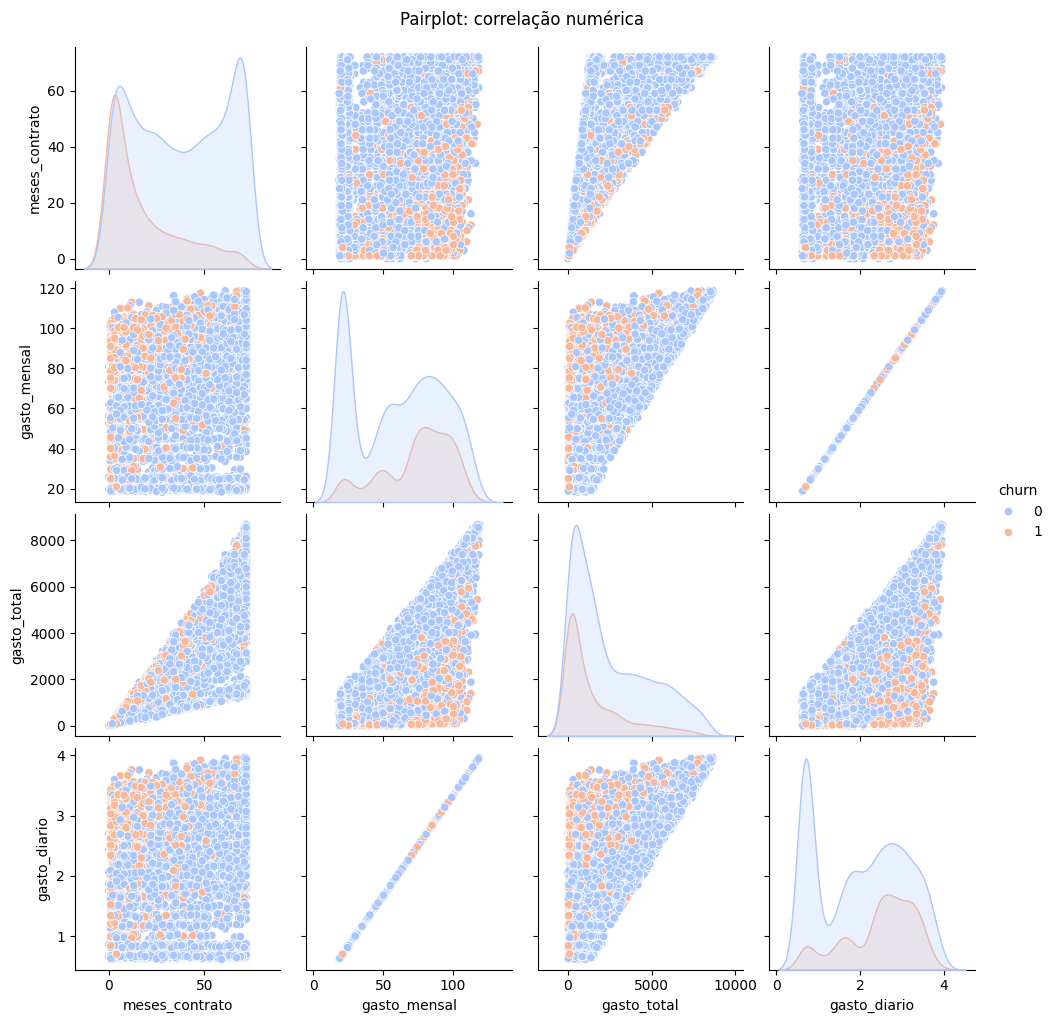

In [82]:
cols_para_plot = ['meses_contrato', 'gasto_mensal', 'gasto_total', 'gasto_diario', 'churn']

sns.pairplot(dados_encoded[cols_para_plot], hue='churn', palette='coolwarm', diag_kind='kde')

plt.suptitle('Pairplot: correlação numérica', y=1.02)
plt.show()

### Separação dos dados

In [83]:
from sklearn.model_selection import train_test_split

x = dados_encoded.drop('churn', axis=1)
y = dados_encoded['churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

print(f"Treino: {x_train.shape[0]} amostras")
print(f"Teste: {x_test.shape[0]} amostras")

Treino: 5282 amostras
Teste: 1761 amostras


### Treinando o modelo

###### DummyClassifier (Modelo de base)

In [84]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

dummy = DummyClassifier()

dummy.fit(x_train, y_train)

y_predict_dummy = dummy.predict(x_test)

print(f"Acurácia do Baseline (Dummy): {accuracy_score(y_test, y_predict_dummy):.4f}")
print("\nMétricas:")
print(classification_report(y_test, y_predict_dummy))

Acurácia do Baseline (Dummy): 0.7348

Métricas:
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1294
           1       0.00      0.00      0.00       467

    accuracy                           0.73      1761
   macro avg       0.37      0.50      0.42      1761
weighted avg       0.54      0.73      0.62      1761



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###### RandomForest (Modelo final)

In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100,
     max_depth=10,          # Limita a profundidade (evita decorar detalhes)
     min_samples_leaf=10,   # Cada folha precisa de pelo menos 10 clientes
     min_samples_split=20,  # Precisa de 20 clientes para tentar criar um novo ramo
     random_state=42,
     class_weight='balanced')

rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)

print(f"Acurácia do Random Forest: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf))

Acurácia do Random Forest: 0.7700

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      1294
           1       0.55      0.76      0.64       467

    accuracy                           0.77      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.77      0.78      1761



Analisando overfitting

In [87]:
y_pred_train = rf_model.predict(x_train)
acc_train = accuracy_score(y_train, y_pred_train)

y_pred_test = rf_model.predict(x_test)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia Treino: {acc_train:.4f}")
print(f"Acurácia Teste: {acc_test:.4f}")
print(f"Diferença: {acc_train - acc_test:.4f}")

### Não houve overfitting

Acurácia Treino: 0.8044
Acurácia Teste: 0.7700
Diferença: 0.0344


###### Arvore de decisão

In [88]:
from sklearn.tree import DecisionTreeClassifier

arvore = DecisionTreeClassifier(max_depth=5, random_state = 5)
arvore.fit(x_train, y_train)

arvore.score(x_test, y_test)

y_predict_arvore = arvore.predict(x_test)

print(f"Acurácia do Random Forest: {accuracy_score(y_test, y_predict_arvore):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_predict_arvore))

Acurácia do Random Forest: 0.7882

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1294
           1       0.61      0.57      0.59       467

    accuracy                           0.79      1761
   macro avg       0.73      0.72      0.72      1761
weighted avg       0.78      0.79      0.79      1761



###### KNN (Com dados padronizados)

In [89]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()

cols_numericas = ['meses_contrato', 'gasto_mensal', 'gasto_total', 'gasto_diario']

x_train_knn = x_train.copy()
x_test_knn = x_test.copy()

x_train_knn[cols_numericas] = scaler.fit_transform(x_train[cols_numericas])
x_test_knn[cols_numericas] = scaler.transform(x_test[cols_numericas])

knn_model = KNeighborsClassifier(n_neighbors=21)
knn_model.fit(x_train_knn, y_train)

y_predict_knn = knn_model.predict(x_test_knn)

print(f"Acurácia do KNN: {accuracy_score(y_test, y_predict_knn):.4f}")
print("\nMétricas:")
print(classification_report(y_test, y_predict_knn))

Acurácia do KNN: 0.7825

Métricas:
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1294
           1       0.60      0.54      0.57       467

    accuracy                           0.78      1761
   macro avg       0.72      0.71      0.71      1761
weighted avg       0.78      0.78      0.78      1761



### Análise de importância de variáveis (Modelo RandomForest)

/tmp/ipykernel_64338/3871730874.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importância', y='Variável', data=df_importancia, palette='viridis')


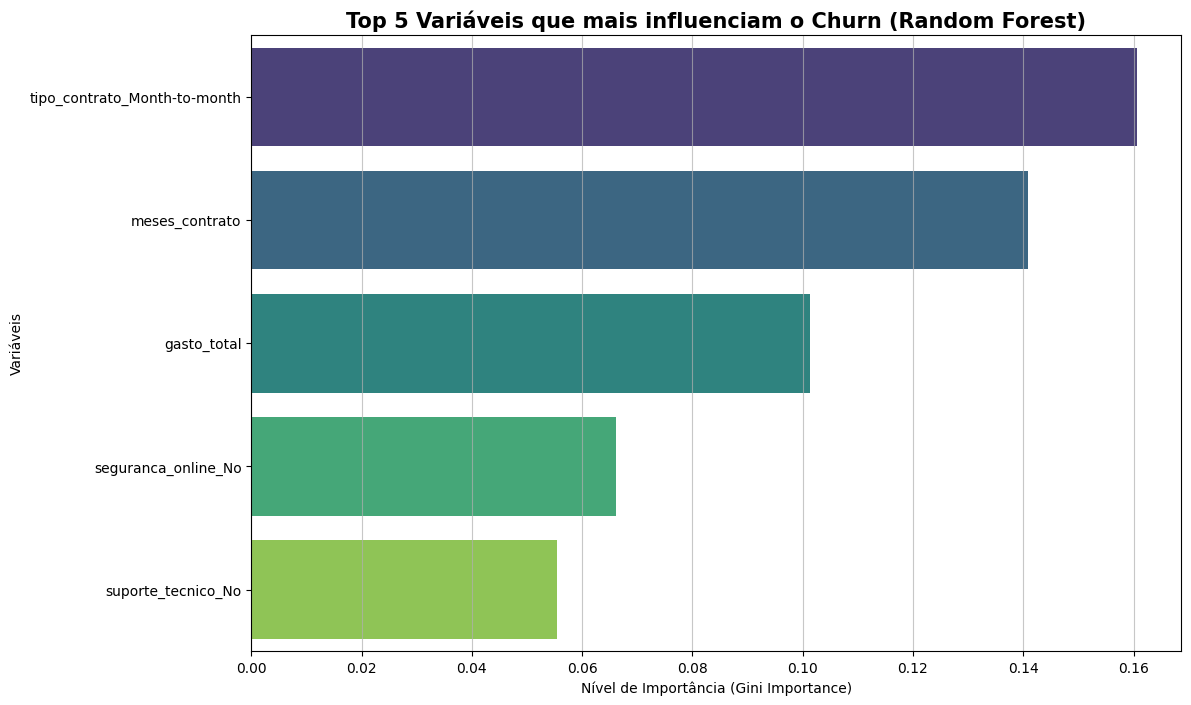

<Figure size 640x480 with 0 Axes>

In [92]:
importancias = rf_model.feature_importances_
importancias

features = x.columns

df_importancia = pd.DataFrame({'Variável': features, 'Importância': importancias})

df_importancia = df_importancia.sort_values(by='Importância', ascending=False).head(5)
df_importancia

plt.figure(figsize=(12, 8))
sns.barplot(x='Importância', y='Variável', data=df_importancia, palette='viridis')

plt.title('Top 5 Variáveis que mais influenciam o Churn (Random Forest)', fontsize=15, fontweight='bold')
plt.xlabel('Nível de Importância (Gini Importance)')
plt.ylabel('Variáveis')
plt.grid(axis='x', alpha=0.7)
plt.show()
plt.savefig('top5_variaveis_churn.png', dpi=300, bbox_inches='tight')


## Relatório Final: Projeto TelecomX (Previsão de Churn)

### 1. Visão Geral e Problema

A TelecomX apresentava uma taxa de **27% de evasão (Churn)**. O objetivo deste projeto foi desenvolver um modelo de Inteligência Artificial capaz de identificar clientes em risco de cancelamento antes que eles tomem a decisão final, permitindo ações de retenção proativas.

### 2. Metodologia Aplicada

* **Tratamento de Dados:** Conversão de categorias em números (**One-Hot Encoding**) para permitir o processamento matemático.
* **Modelagem:** Foi comparado algoritmos como KNN e Árvore de Decisão, selecionando o **Random Forest** como o modelo final devido à sua robustez e capacidade de generalização comparado a Árvore de decisão (seu derivado).
* **Ajuste de Hiperparâmetros:** Foi combatido o *Overfitting* (reduzindo a diferença entre treino e teste de 21% para apenas **3%**), garantindo um modelo estável para dados reais.

### 3. Resultados das Métricas

O modelo final superou o "chute estatístico" (Baseline) e entregou resultados equilibrados:



| Métrica | Resultado | O que significa na prática? |
| --- | --- | --- |
| **Acurácia** | **77,12%** | O modelo acerta o destino de quase 8 em cada 10 clientes. |
| **Recall (Churn)** | **49,00%** | Identificamos metade de todos os clientes que pretendem sair. |
| **Precisão (Churn)** | **60,00%** | De cada 10 alertas, 6 são cancelamentos reais (eficiência de custo). |
| **F1-Score** | **0,54** | O equilíbrio ideal entre detecção e precisão. |

### 4. Insights

O modelo revelou que o Churn não é aleatório. Os principais fatores de risco são:

1. **Contratos Mensais (Month-to-month):** Representam o maior risco de saída imediata.
2. **Tecnologia de Fibra Óptica:** Apesar da velocidade, esse grupo tem alta taxa de evasão.
3. **Falta de Serviços Adicionais:** Clientes sem "Segurança Online" ou "Suporte Técnico" são mais propensos a cancelar.

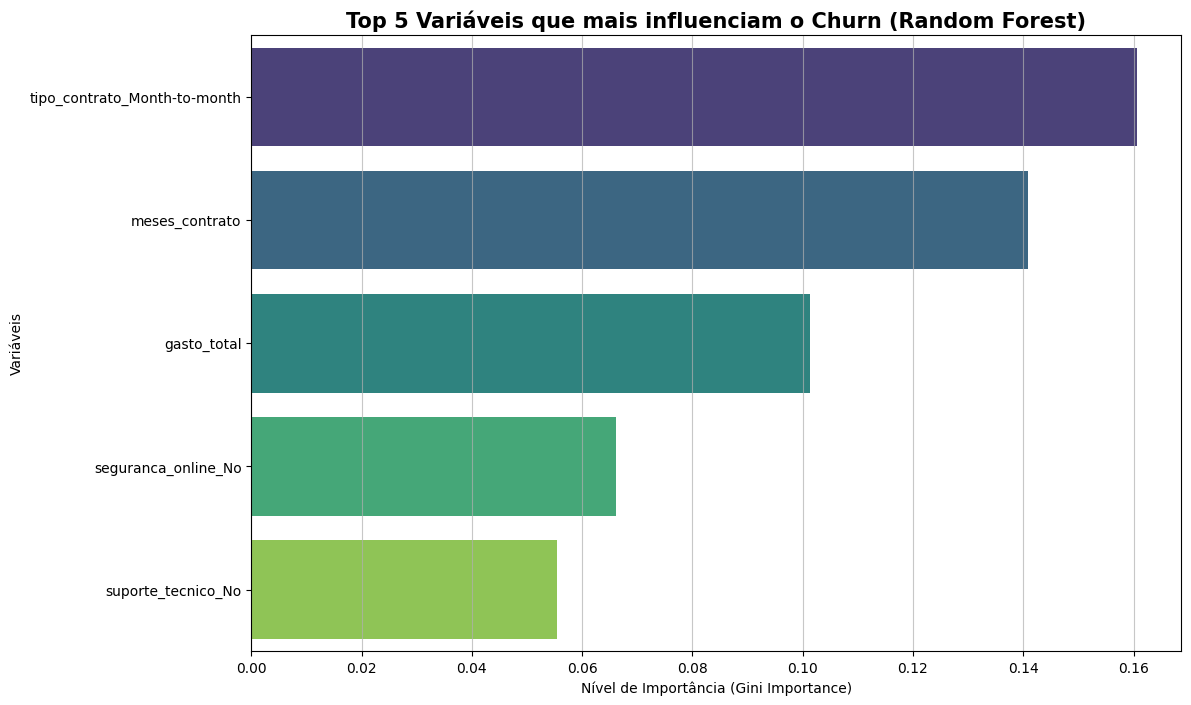


### 5. Recomendação de Negócio

Para reduzir o Churn de 27%, a TelecomX deve:

* **Migrar contratos:** Criar incentivos para que clientes mensais migrem para contratos anuais.

* **Revisar a Fibra Óptica:** Investigar se a taxa de saída na fibra deve-se a preço ou estabilidade do sinal.

* **Cross-selling de Segurança:** Oferecer pacotes de Segurança Online como bônus para aumentar a "fidelidade" do cliente.
